#### 1. Set up the reaction graph from DFT data 

In [3]:
from arcs.generate import GraphGenerator

graph = GraphGenerator().from_file(
    filename='../src/arcs/data/quantum_data.json',
    temperature=248,
    pressure=20,
    max_reaction_length=5,
    log_K = False
)

/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: CH3CHO: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)
/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: H2O2: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)
/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: H2SO4: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)
/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: NOHSO4: 2 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)
/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: CH3_CO_CH3: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)
/Users/badw/github-projects/arcs/src/arcs/generate.py:536: UserWarning: CH3_C6H5: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']

#### 2. Sample the `graph`

In [ ]:
from arcs.traversal import Traversal
from arcs.generate import GenerateInitialConcentrations

gic = GenerateInitialConcentrations(graph=graph).update_ic(
    {'H2O':30,'O2':10,'SO2':5,'H2S':0,'NO2':10}
    )

t = Traversal(graph=graph)

data = t.sample(initial_concentrations=gic,ncpus=8,nsamples=1000,**{"use_chempy":True})

  0%|          | 0/1000 [00:00<?, ?it/s]

#### 3. generate reaction statistics

In [8]:
from arcs.analysis import AnalyseSampling
import pandas as pd 

analysis = AnalyseSampling()
stats = pd.Series(analysis.reaction_statistics(data)).sort_values(ascending=False)
stats.head(20)

1 C2H5OH + 1 NO2 = 1 C2H6O2 + 1 NO       368
2 NO2 + 1 C2H6O2 = 2 HNO2 + 2 CH2O       234
1 NO3 + 1 C2H5OH = 1 NO2 + 1 C2H6O2      211
2 NO2 + 1 C2H6O2 = 1 CH3COOH + 2 HNO2    157
1 C2H6O2 = 1 H2O + 1 CH4 + 1 CO          152
1 O3 + 1 C2H6O2 = 1 H2O + 2 HCOOH        126
2 CH3OH + 2 NO2 = 2 HNO2 + 1 C2H6O2      119
1 C2H6O2 = 1 H2O + 1 CH3CHO               86
2 H2O + 1 C2H6O2 = 5 H2 + 2 CO2           63
1 O2 + 1 C2H6O2 = 1 H2CO3 + 1 CH3OH       63
1 C2H6O2 + 1 H2O2 = 2 H2O + 2 CH2O        55
3 O2 + 1 C2H6O2 = 2 H2CO3 + 1 H2O2        48
6 NO2 + 1 C2H6O2 = 6 HNO2 + 2 CO          47
2 C2H5OH + 2 NO2 = 1 N2O2 + 2 C2H6O2      47
2 H2O2 = 2 H2O + 1 O2                     46
1 H2 + 1 C2H6O2 = 1 H2O + 1 C2H5OH        46
2 CH4 + 1 HNO2 = 1 NH3 + 1 C2H6O2         40
1 O3 + 2 CH4 = 1 H2O + 1 C2H6O2           39
1 HNO3 + 1 C2H5OH = 1 HNO2 + 1 C2H6O2     39
1 O2 + 1 C2H6O2 = 2 HCOOH + 1 H2          32
dtype: int64

#### 4. generate mean concentrations and differences

In [9]:
average_data = pd.DataFrame(analysis.average_sampling(data))
average_data = average_data.loc[~(average_data==0).all(axis=1)]
average_data.sort_values(by='diff',inplace=True)
average_data = average_data[average_data["mean"].round(3) !=0]

print(average_data.round(3).to_string())

         initial    mean    diff    sem     std      var
C2H6O2      50.0  37.468 -12.532  0.328  18.289  334.483
NO2         10.0   6.209  -3.791  0.087   4.837   23.397
O2          10.0   7.506  -2.494  0.077   4.273   18.263
SO2          5.0   5.000   0.000  0.000   0.000    0.000
N2O          0.0   0.013   0.013  0.005   0.254    0.064
HCN          0.0   0.026   0.026  0.006   0.358    0.128
HNO3         0.0   0.141   0.141  0.017   0.947    0.897
NO           0.0   0.172   0.172  0.021   1.184    1.402
NH3          0.0   0.222   0.222  0.026   1.474    2.174
H2O2         0.0   0.402   0.402  0.029   1.590    2.527
CH3OH        0.0   0.557   0.557  0.072   3.995   15.961
CH3COOH      0.0   0.586   0.586  0.029   1.601    2.562
H2CO3        0.0   0.935   0.935  0.049   2.742    7.520
HCOOH        0.0   1.439   1.439  0.097   5.401   29.167
CH2O         0.0   1.523   1.523  0.073   4.054   16.438
CH3CHO       0.0   2.800   2.800  0.203  11.309  127.883
CO2          0.0   3.157   3.15

#### 5. Plot 

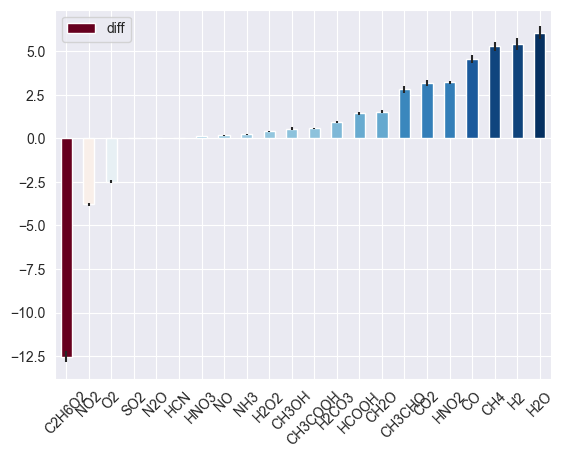

In [10]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
sns.set_style('darkgrid')
sns.set_palette('pastel')


norm = colors.Normalize(
    vmin=average_data['diff'].min(), vmax=average_data['diff'].max()
    )
cmap = plt.get_cmap(name='RdBu')  # or any other colormap

bar_colors = [cmap(norm(value)) for value in average_data['diff']]

average_data.plot.bar(y='diff',yerr='sem',color=bar_colors,rot=45)

plt.show()

#### 5. generate a `pyvis` graph 

In [38]:
pyvis_kwargs = {'width':'50%','notebook':False,"font_color":'white','directed':True}
g = analysis.result_to_pyvis(data,head=10,**pyvis_kwargs)
g.save_graph(name="example_pyvis_graph.html")

In [ ]:
! open example_pyvis_graph.html

: 